In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Crop_recommendation.csv')

##**EXPLORATORY DATA ANALYSIS**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
df.shape

(2200, 8)

In [6]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [8]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [13]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [34]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [35]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
rice,4.545455
maize,4.545455
chickpea,4.545455
kidneybeans,4.545455
pigeonpeas,4.545455
mothbeans,4.545455
mungbean,4.545455
blackgram,4.545455
lentil,4.545455


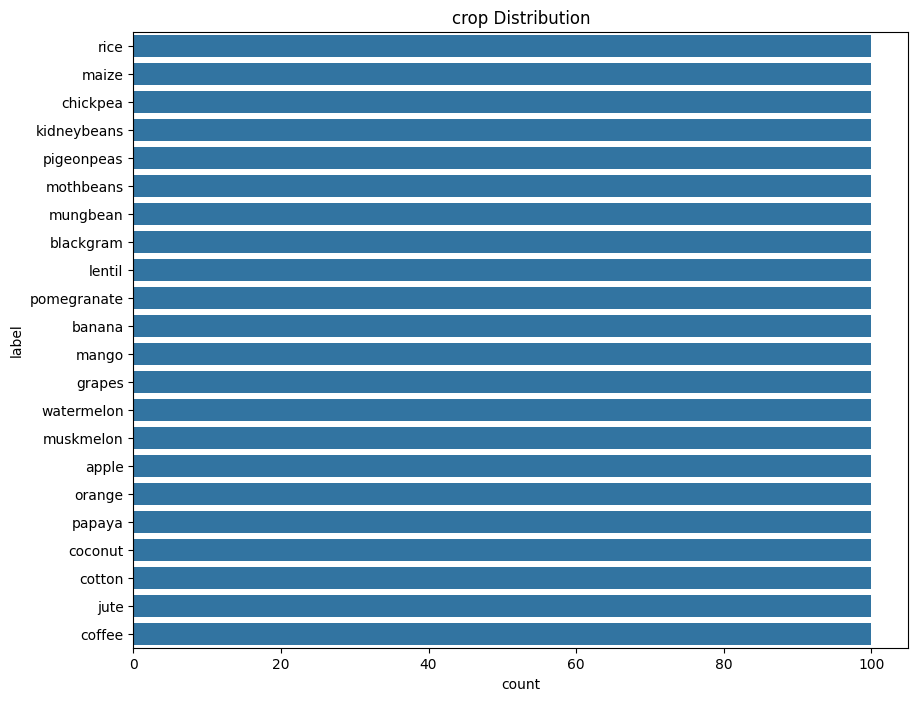

In [43]:
plt.figure(figsize=(10,8))
sns.countplot(y='label',data=df, order=df['label'].value_counts().index)
plt.title("crop Distribution")
plt.show()

### Insight: Crop Type Distribution (Target Variable)
- The dataset is **perfectly balanced**: every crop has **exactly 100 samples**.
- 22 unique crops in total → multi-class classification with equal representation.
- No imbalance → no need for SMOTE, class_weight, or oversampling.
- This balance makes the model learn fairly for every crop.

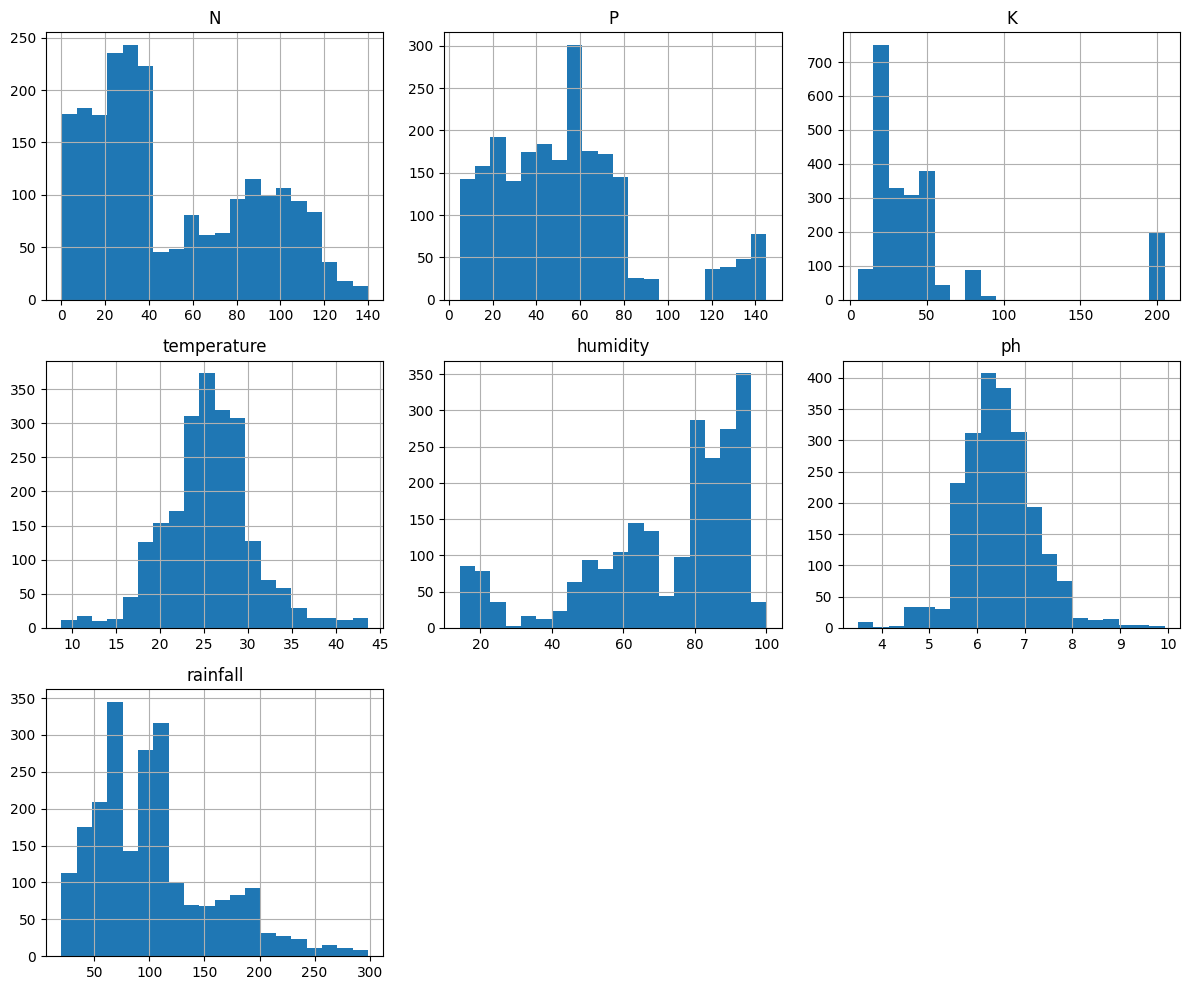

In [44]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

### Insight: Distribution of Numeric Features
- Temperature: Mostly 20–35°C (typical Indian crop-growing range).
- Humidity: Peak at 50–80% (common in monsoon and post-monsoon seasons).
- Rainfall: Many low values + some very high (up to ~300 mm) → reflects dry vs monsoon crops.
- N, P, K: Many low/zero values → many soils are nutrient-deficient (realistic for Indian agriculture).
- pH: Ranges from ~4 to ~9 → covers acidic to alkaline soils.
- These distributions are realistic and show variation in Indian farming conditions.

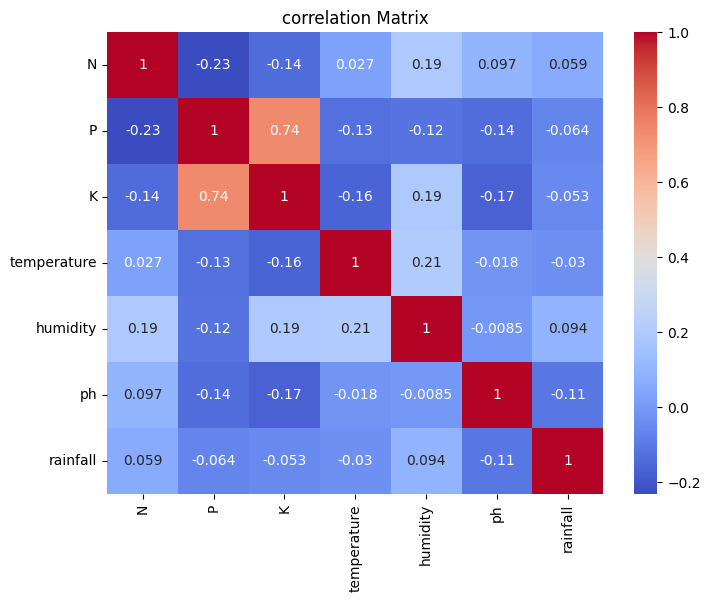

In [45]:
plt.figure(figsize=(8,6))
numeric_df=df.drop('label', axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("correlation Matrix")
plt.show()

### Insight: Correlation Heatmap (Numeric Features)
- Strong positive correlation between **N and P** (around 0.5–0.6) — farmers often apply these nutrients together.
- **Temperature and humidity** show moderate positive correlation (0.5+) — typical in many Indian regions.
- Very weak correlation between most other pairs → features are mostly independent (good for the model).
- No severe multicollinearity (no value > 0.8) → we can safely keep all numeric features.

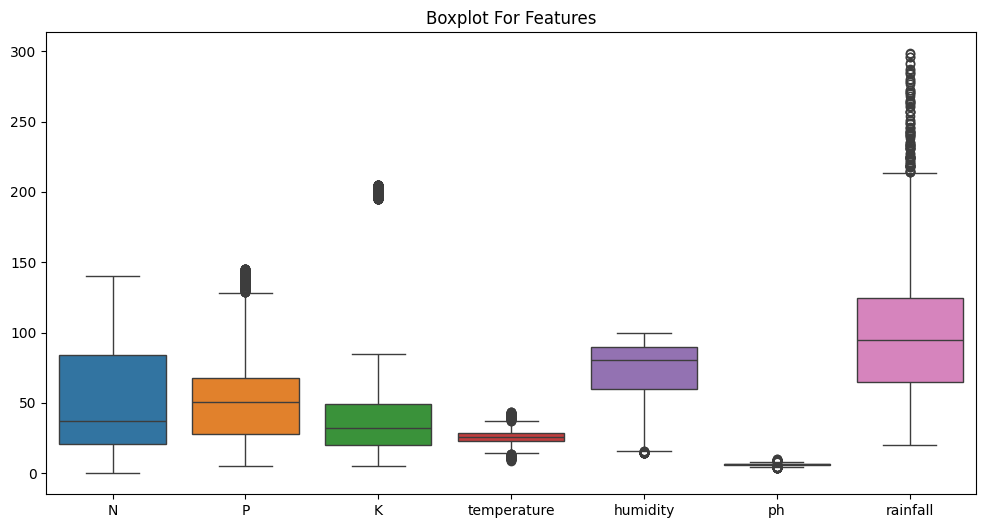

In [47]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop('label', axis=1))
plt.title("Boxplot For Features")
plt.show()

### Insight: Boxplots & Outlier Analysis
- Rainfall has the most high outliers (up to 298 mm) — natural for monsoon-dependent crops like rice and jute.
- Potassium (K) has several high outliers (up to 205) — valid for potassium-loving crops like grapes, cotton, and apple.
- Temperature and pH also have some extreme points — normal variation in Indian climate and soil.
- **Outliers are natural** (not errors) — we will **keep them** because Random Forest handles them well.
- No impossible values (e.g., negative nutrients).

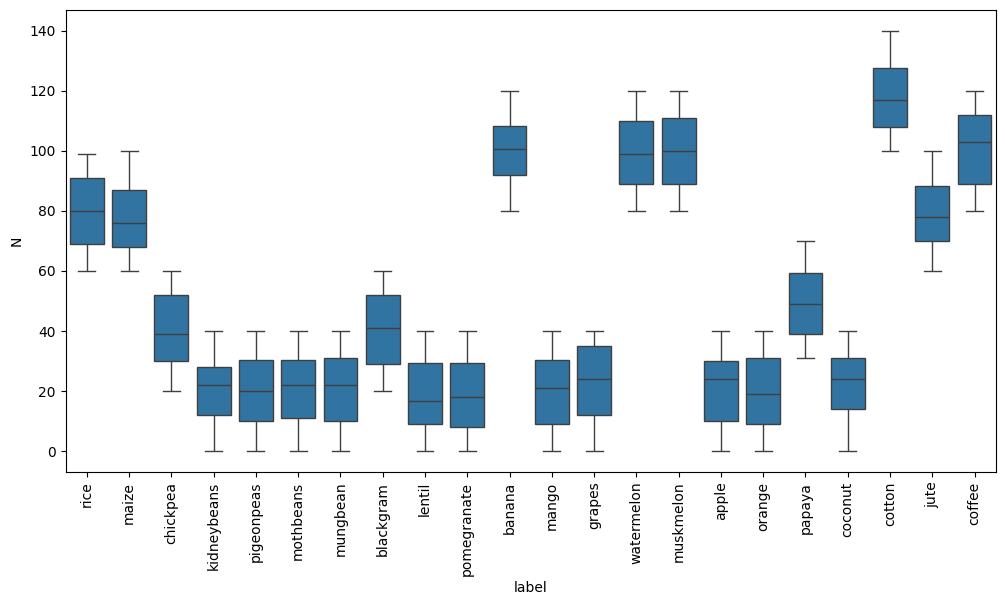

In [48]:
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='N', data=df)
plt.xticks(rotation=90)
plt.show()

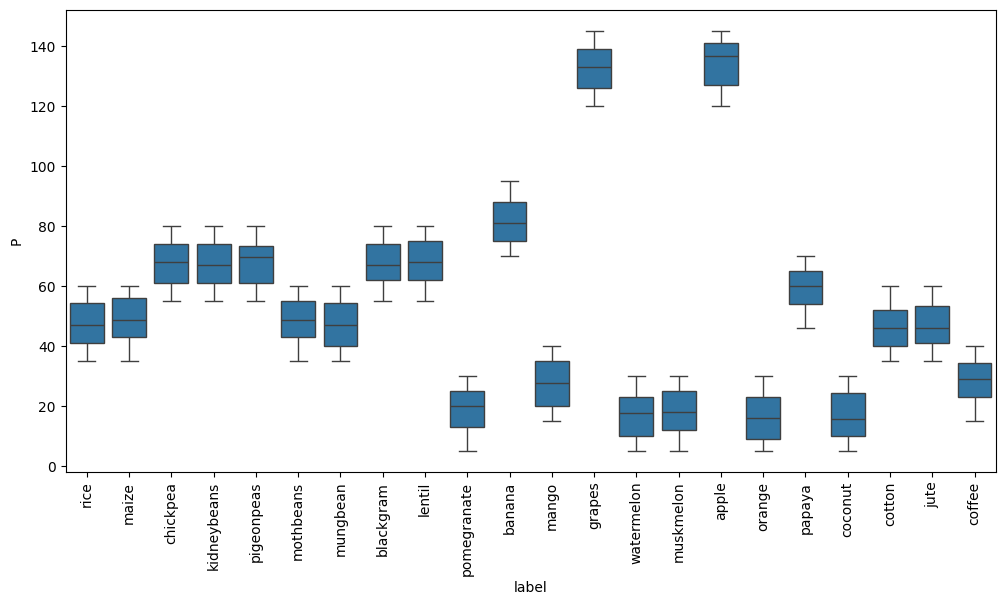

In [49]:
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='P', data=df)
plt.xticks(rotation=90)
plt.show()

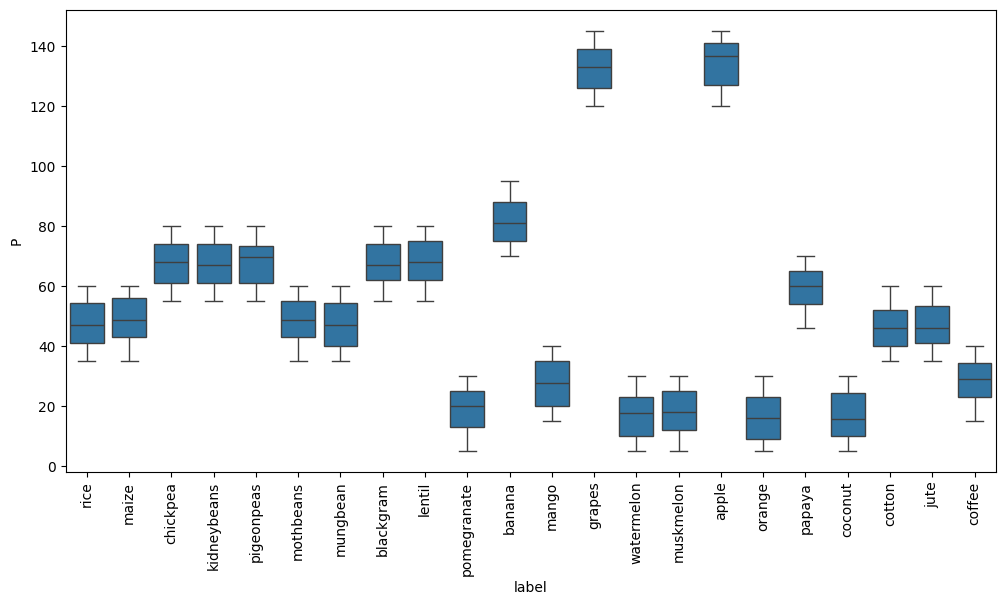

In [50]:
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='P', data=df)
plt.xticks(rotation=90)
plt.show()

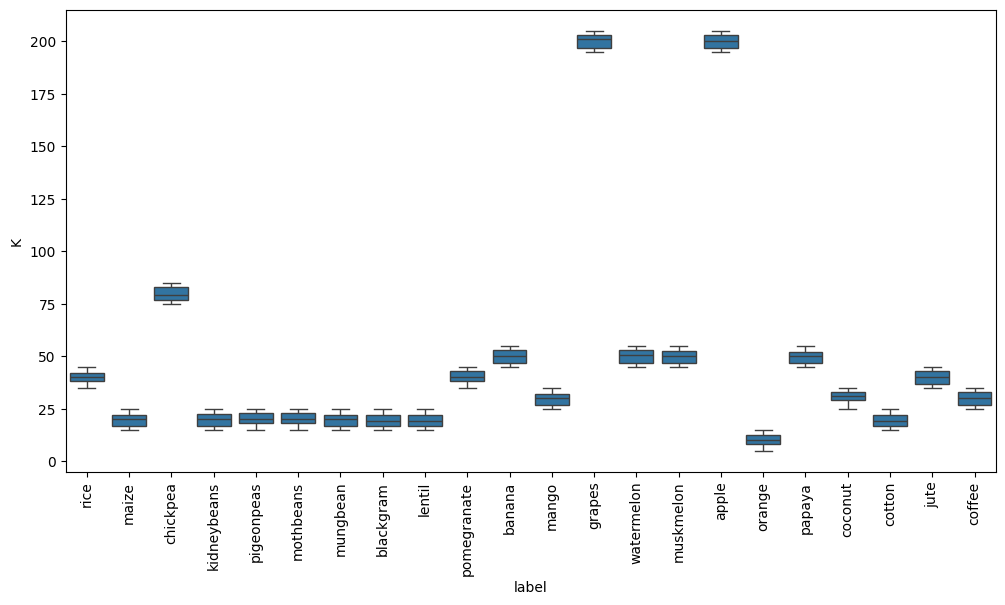

In [51]:
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='K', data=df)
plt.xticks(rotation=90)
plt.show()

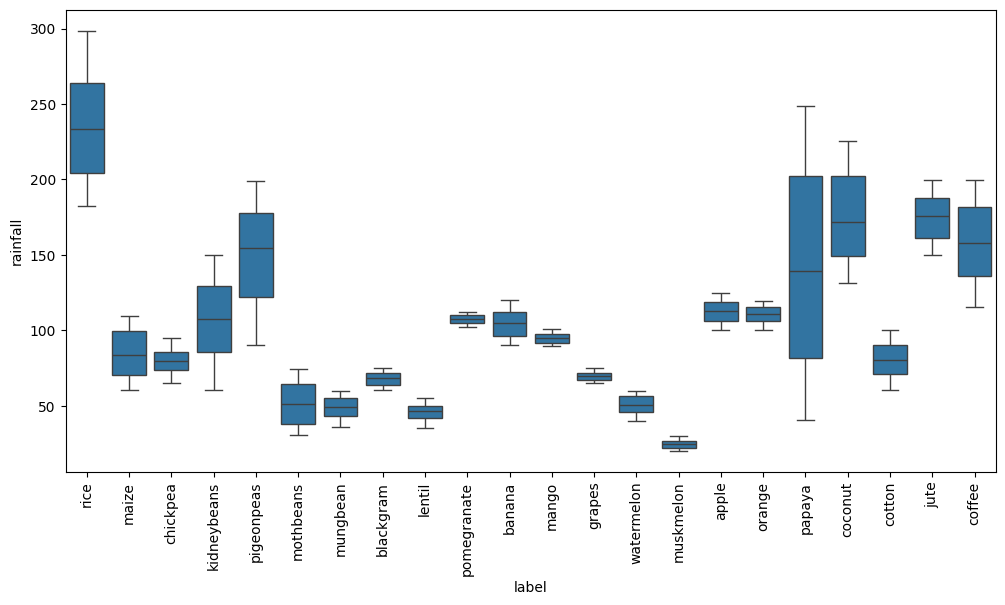

In [52]:
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='rainfall', data=df)
plt.xticks(rotation=90)
plt.show()

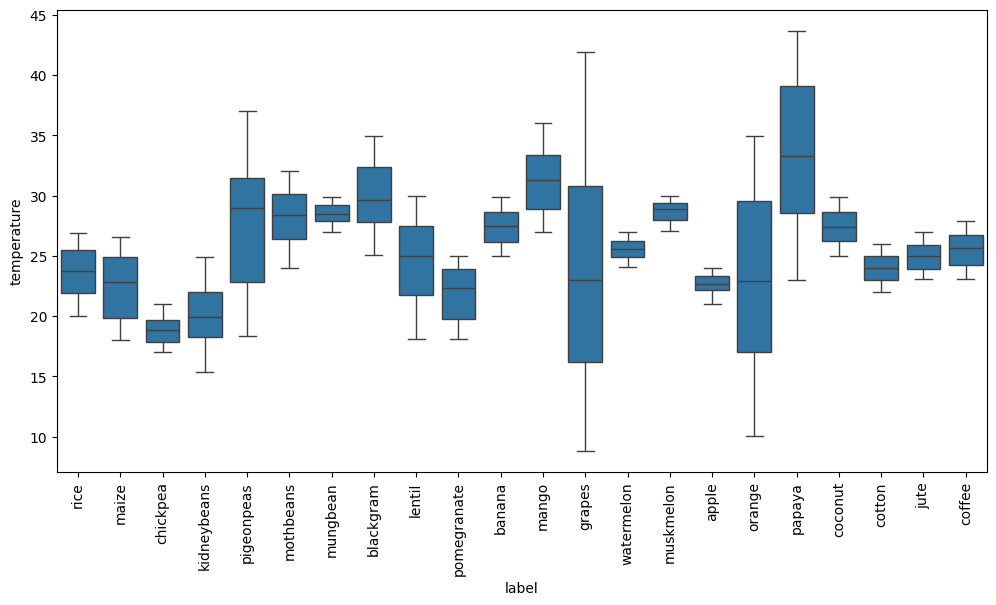

In [53]:
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='temperature', data=df)
plt.xticks(rotation=90)
plt.show()

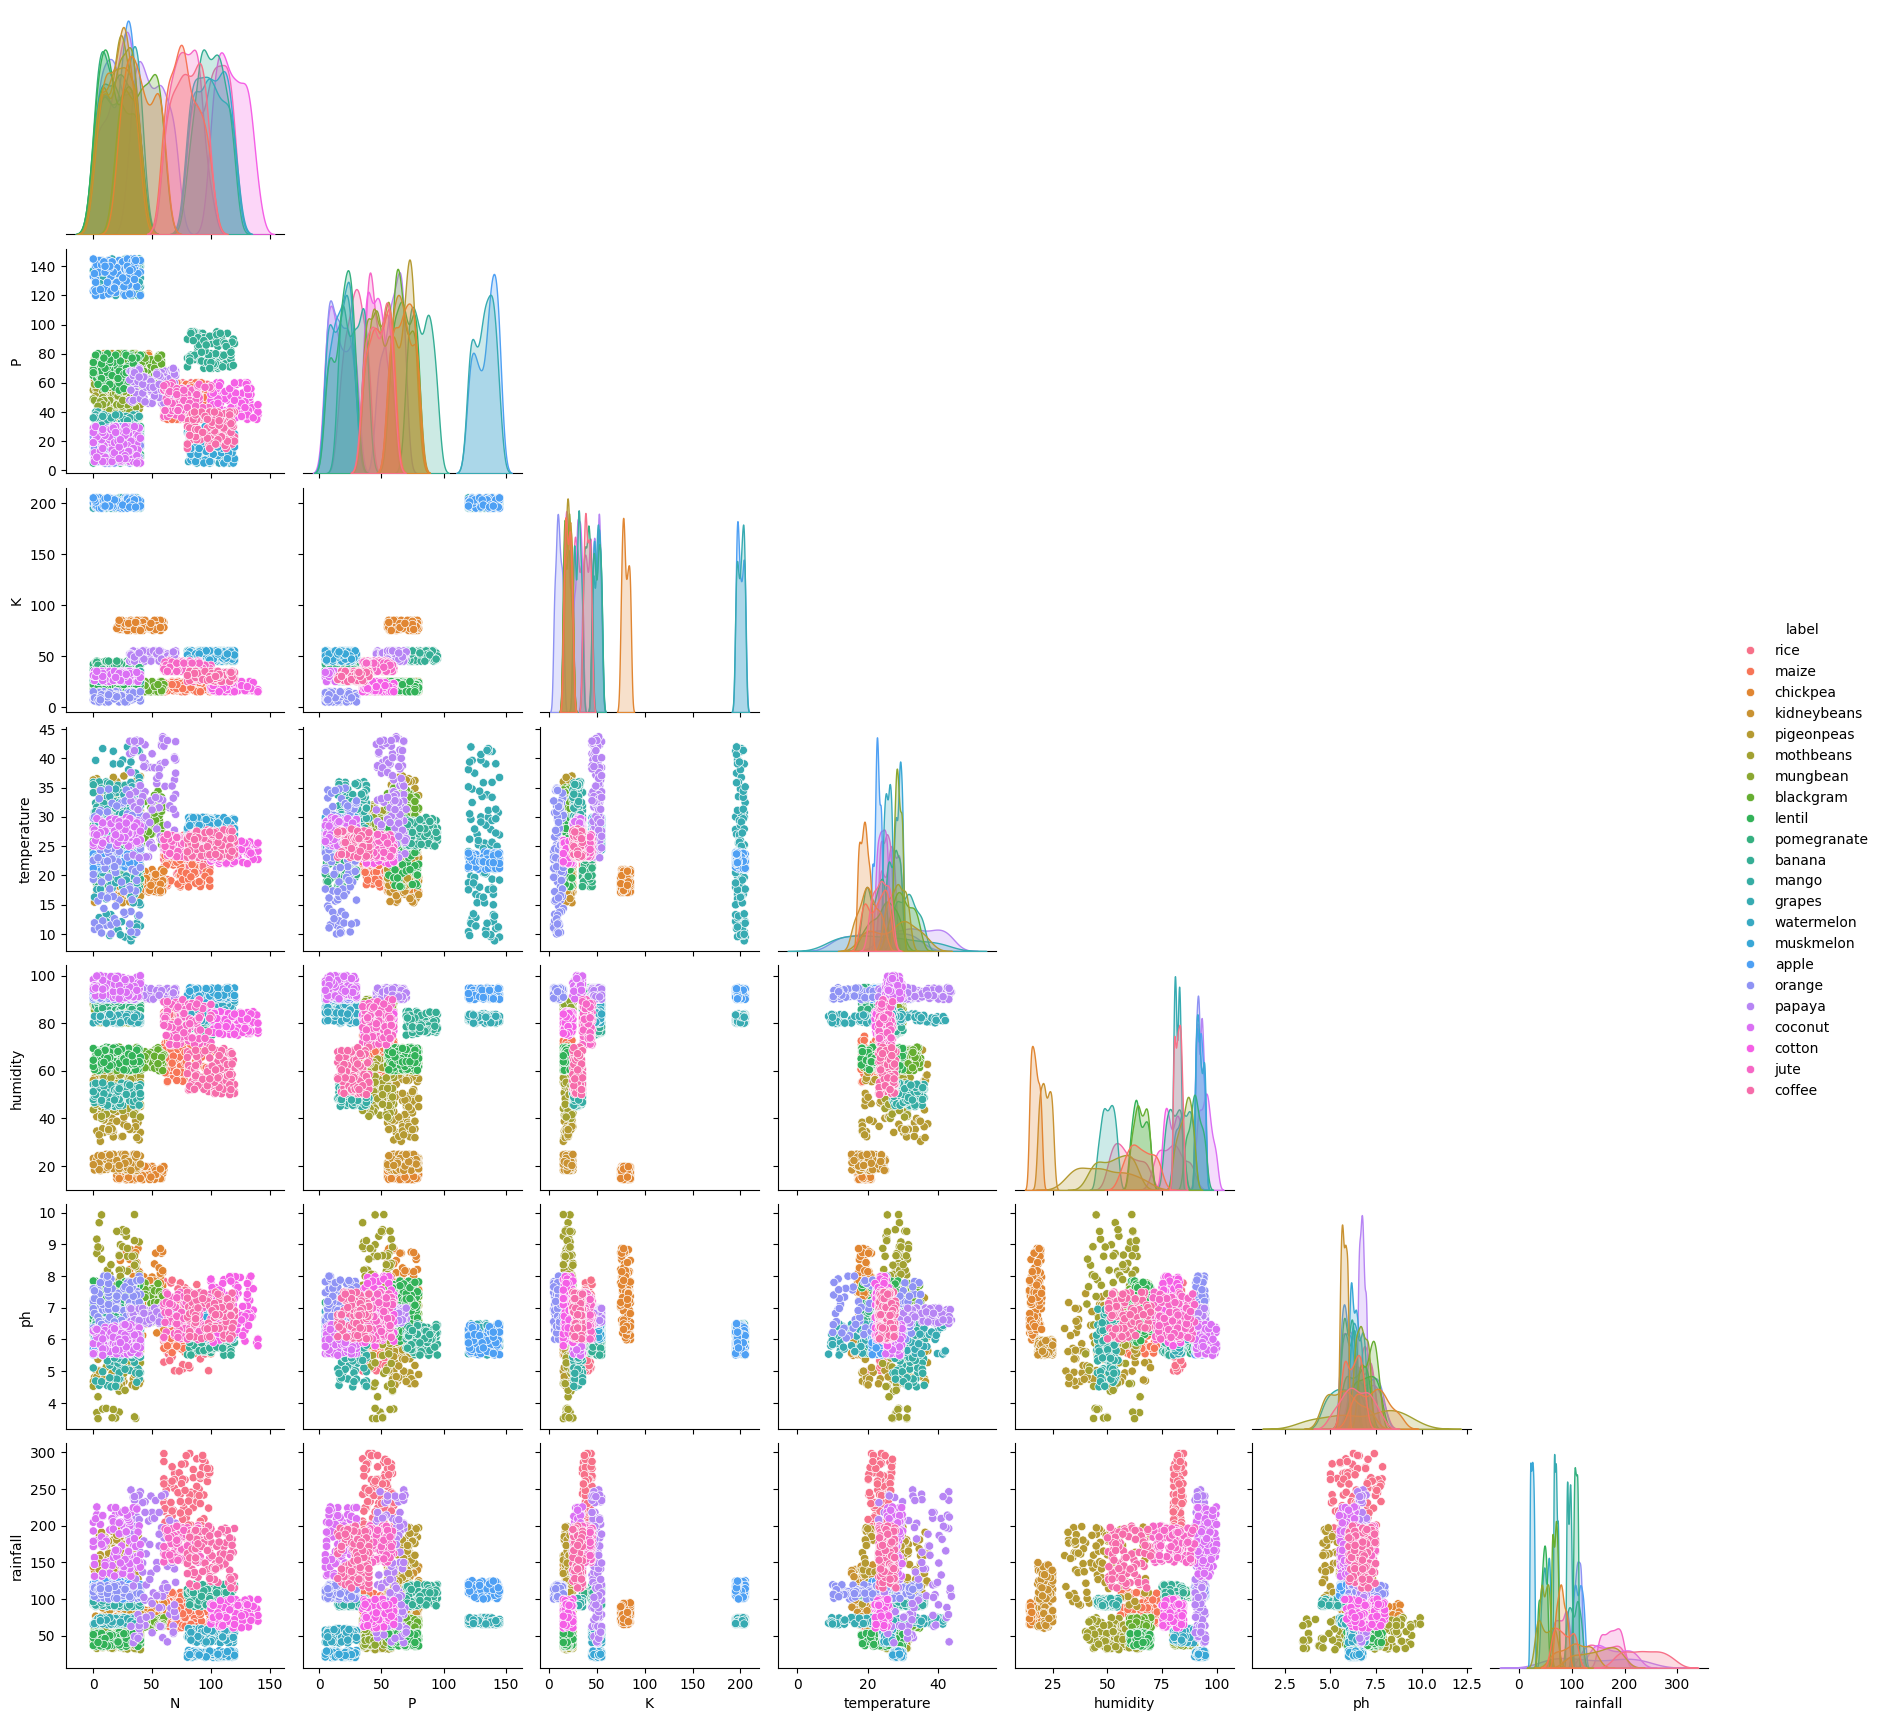

In [54]:
sns.pairplot(df, hue='label', corner=True)
plt.show()

### Insight: Pairplot (Relationships between Key Features)
- Clear clusters visible when colored by Crop Type → different crops have distinct patterns in N-P-K, temperature, and rainfall.
- Sugarcane, rice, and jute often appear in high-rainfall + high-humidity zones.
- Apple, grapes, and orange cluster in low-rainfall + moderate temperature zones.
- This visual separation confirms that the features are powerful for distinguishing crops.

### Overall EDA Conclusions & Project Relevance

- The dataset is clean: No missing values, no duplicates, no impossible values.
- Perfectly balanced target (22 crops, exactly 100 samples each) → no imbalance handling needed.
- Outliers in rainfall and potassium are **natural** (monsoon crops + potassium-loving crops) — kept as-is.
- Strong negative correlation between some nutrients and positive between temperature-humidity → realistic Indian farming patterns.
- Clear crop preferences visible (e.g., rice needs high rain, apple needs cooler climate).
- These insights confirm the data is ideal for building a highly accurate Crop Recommendation System that can help farmers in Maharashtra and India choose the best crop based on soil and weather.

##**DATA PREPROCESSING AND FEATURE ENGINEERING**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [19]:
X = df.drop('label', axis=1)
y = df['label']

In [23]:
X.shape , y.shape

((2200, 7), (2200,))

In [40]:
numeric_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
    ])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
X_train.shape[0] , X_test.shape[0]

(1760, 440)

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [29]:
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)

In [30]:
X_train_processed.shape , X_test_processed.shape

((1760, 7), (440, 7))

In [31]:
len(np.unique(y_train_encoded))

22

In [33]:
le_target.classes_

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

##**MODEL BUILDING AND TRAINING**

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Baseline Model

In [55]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial',
    solver='lbfgs'
)
lr_model.fit(X_train_processed, y_train_encoded)
y_pred_lr = lr_model.predict(X_test_processed)

In [56]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train_encoded)
y_pred_rf = rf_model.predict(X_test_processed)

##**MODEL EVALUATION AND COMPARISON**

In [65]:
from sklearn.metrics import accuracy_score,recall_score, precision_score ,f1_score , classification_report

Logistic Regression Baseline Model

In [68]:
print(f"Accuracy  : {accuracy_score(y_test_encoded, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test_encoded, y_pred_lr, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test_encoded, y_pred_lr, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test_encoded, y_pred_lr, average='weighted'):.4f}")

print(classification_report(y_test_encoded, y_pred_lr, target_names=le_target.classes_))

Accuracy  : 0.9727
Precision : 0.9740
Recall    : 0.9727
F1-Score  : 0.9725
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
     

Random Forest

In [69]:
print(f"Accuracy  : {accuracy_score(y_test_encoded, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test_encoded, y_pred_rf, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test_encoded, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test_encoded, y_pred_rf, average='weighted'):.4f}")

print(classification_report(y_test_encoded, y_pred_rf, target_names=le_target.classes_))

Accuracy  : 0.9955
Precision : 0.9957
Recall    : 0.9955
F1-Score  : 0.9955
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
     